Libraries imported successfully!
TensorFlow version: 2.13.0

Dataset shape: (11162, 17)

First few rows:
    age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown    

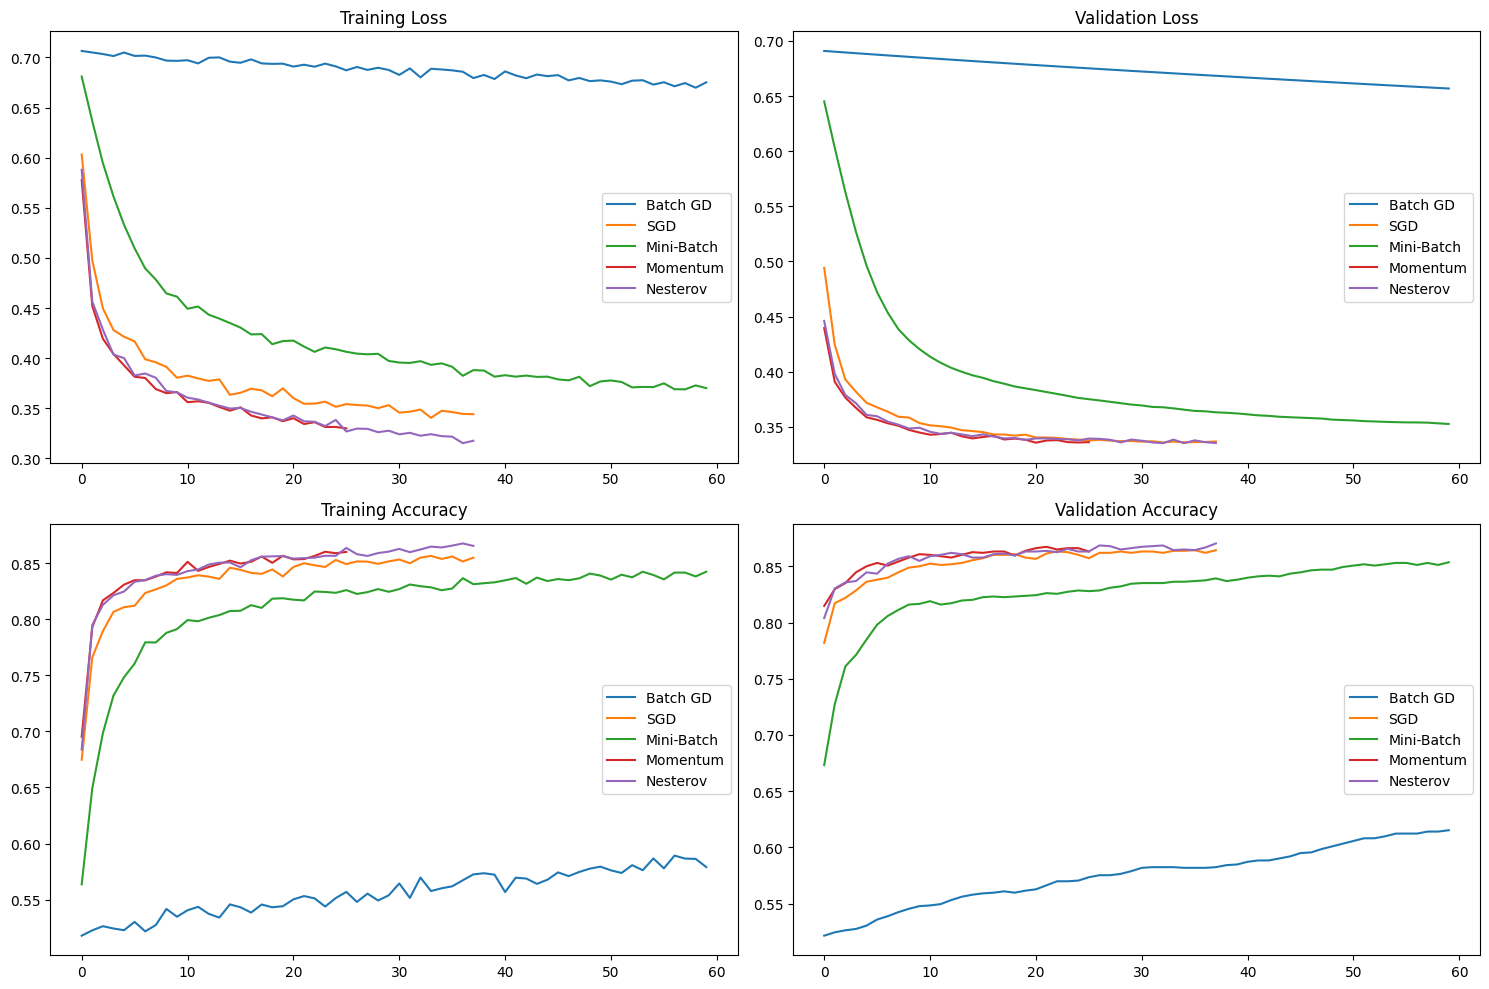


Analyzing Effect of Mini-Batch Size


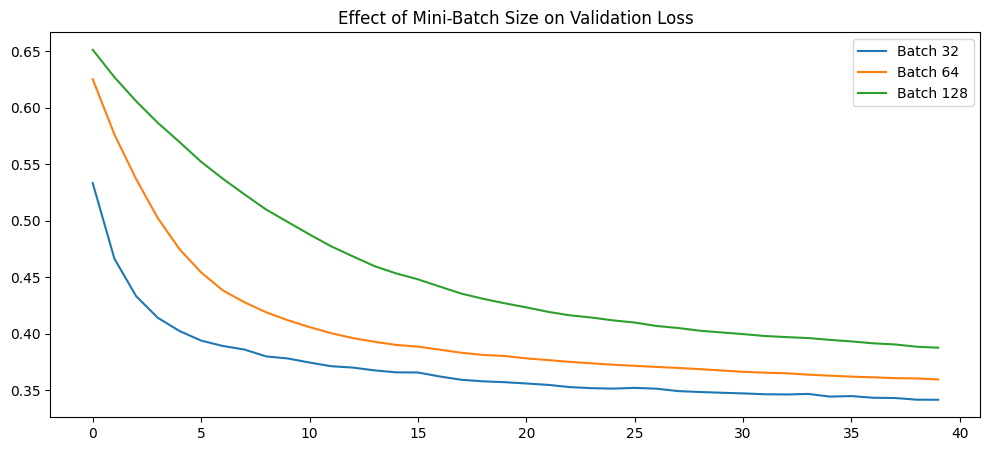


Analyzing Learning Rate Effect


In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

# =====================================================
# 1. RANDOM SEED
# =====================================================
SEED = 77
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =====================================================
# 2. LOAD DATASET
# =====================================================
df = pd.read_csv("bank.csv")

print("\nDataset shape:", df.shape)
print("\nFirst few rows:\n", df.head())

# =====================================================
# 3. PREPROCESSING
# =====================================================
df.replace("unknown", np.nan, inplace=True)
df.ffill(inplace=True)

df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})

X = df.drop("deposit", axis=1)
y = df["deposit"]

X = pd.get_dummies(X, drop_first=True)

print("\nFeature shape after encoding:", X.shape)

# =====================================================
# 4. SPLITTING 70/15/15
# =====================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("\nTraining set size:", len(X_train), f"({len(X_train)/len(X)*100:.1f}%)")
print("Validation set size:", len(X_val), f"({len(X_val)/len(X)*100:.1f}%)")
print("Test set size:", len(X_test), f"({len(X_test)/len(X)*100:.1f}%)")

# =====================================================
# 5. SCALING
# =====================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =====================================================
# 6. MODEL ARCHITECTURE (FACULTY ALIGNED)
# =====================================================
def build_model(input_dim, optimizer):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# =====================================================
# 7. OPTIMIZERS
# =====================================================
LR = 0.009

optimizers = {
    "Batch GD": SGD(learning_rate=LR),
    "SGD": SGD(learning_rate=LR),
    "Mini-Batch": SGD(learning_rate=LR),
    "Momentum": SGD(learning_rate=LR, momentum=0.87),
    "Nesterov": SGD(learning_rate=LR, momentum=0.87, nesterov=True)
}

batch_sizes = {
    "Batch GD": len(X_train),
    "SGD": 16,              # optimized but still stochastic
    "Mini-Batch": 64,
    "Momentum": 64,
    "Nesterov": 64
}

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

histories = {}
times = {}
models = {}

# =====================================================
# 8. TRAINING LOOP (MAX 60 EPOCHS)
# =====================================================
for name, optimizer in optimizers.items():

    print("\n==============================")
    print("Training with", name)
    print("==============================")

    model = build_model(X_train.shape[1], optimizer)

    start = time.time()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=batch_sizes[name],
        callbacks=[early_stop],
        verbose=1
    )

    end = time.time()

    histories[name] = history
    times[name] = end - start
    models[name] = model

# =====================================================
# 9. TRAINING & VALIDATION GRAPHS
# =====================================================
fig, axes = plt.subplots(2, 2, figsize=(15,10))

for name, history in histories.items():
    axes[0,0].plot(history.history['loss'], label=name)
    axes[0,1].plot(history.history['val_loss'], label=name)
    axes[1,0].plot(history.history['accuracy'], label=name)
    axes[1,1].plot(history.history['val_accuracy'], label=name)

axes[0,0].set_title("Training Loss")
axes[0,1].set_title("Validation Loss")
axes[1,0].set_title("Training Accuracy")
axes[1,1].set_title("Validation Accuracy")

for ax in axes.flat:
    ax.legend()

plt.tight_layout()
plt.show()

# =====================================================
# 10. MINI-BATCH SIZE ANALYSIS
# =====================================================
print("\nAnalyzing Effect of Mini-Batch Size")

batch_tests = [32, 64, 128]
batch_histories = {}

for bs in batch_tests:
    model = build_model(X_train.shape[1], SGD(learning_rate=LR))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=bs,
        callbacks=[early_stop],
        verbose=0
    )
    batch_histories[bs] = history

plt.figure(figsize=(12,5))
for bs, hist in batch_histories.items():
    plt.plot(hist.history["val_loss"], label=f"Batch {bs}")
plt.title("Effect of Mini-Batch Size on Validation Loss")
plt.legend()
plt.show()

# =====================================================
# 11. LEARNING RATE ANALYSIS
# =====================================================
print("\nAnalyzing Learning Rate Effect")

lr_values = [0.001, 0.01, 0.05]
lr_histories = {}

for lr in lr_values:
    model = build_model(X_train.shape[1], SGD(learning_rate=lr))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    lr_histories[lr] = history

plt.figure(figsize=(12,5))
for lr, hist in lr_histories.items():
    plt.plot(hist.history["val_loss"], label=f"LR {lr}")
plt.title("Effect of Learning Rate on Validation Loss")
plt.legend()
plt.show()

# =====================================================
# 12. BEST MODEL SELECTION
# =====================================================
val_scores = {name: hist.history['val_accuracy'][-1] for name, hist in histories.items()}

print("\nValidation Accuracy Comparison:")
for name, score in val_scores.items():
    print(name, ":", round(score,4))

best_name = max(val_scores, key=val_scores.get)
best_model = models[best_name]

print("\nBest Optimizer:", best_name)

# =====================================================
# 13. TEST EVALUATION
# =====================================================
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nTest Performance")
print("Accuracy:", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall:", round(recall,4))
print("F1 Score:", round(f1,4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - " + best_name)
plt.show()

# =====================================================
# 14. COMPARATIVE SUMMARY
# =====================================================
print("\n==============================")
print("COMPARATIVE ANALYSIS SUMMARY")
print("==============================")

for name in histories:
    epochs = len(histories[name].history["loss"])
    print(name)
    print("  Epochs:", epochs)
    print("  Training Time:", round(times[name],2), "sec")
    print("  Final Val Accuracy:", round(histories[name].history["val_accuracy"][-1],4))
    print("----------------------------------")

print("\nANALYSIS COMPLETE")